# STAT 207 Homework 2 [25 points]

## Cleaning, Wrangling, and Reshaping Data

Due: Tuesday, September 10, end of day (11:59 pm CT)

Late Submissions accepted until Wednesday, September 11 at noon

<hr>

## Python Component

Run the following code chunk to import the pandas package needed for this assignment and the optional visualization packages:

- pandas
- matplotlib.pyplot
- seaborn

In [119]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

## 1. Read in and Clean the Data [2.5 points]

Medium is a website where anyone can post an article, share a written story, or create a helpful tutorial to share.  Medium has publications, which are curated collections of articles focused on specific topics.  The data that we will analyze here is about articles collected from Medium publications focused on data science topics.  The original data is accessible here: https://www.kaggle.com/datasets/arnabchaki/medium-articles-dataset

The kaggle data has been slightly modified and is available in the medium.csv file located in this same folder, with primary updates to the date variable.

Read this file in.  Be sure that any missing values are read in appropriately, and show your process for doing so.

No need to drop any observations with missing values for this assignment.

In [120]:
df = pd.read_csv('medium.csv')
df

,id,url,title,subtitle,claps,responses,reading_time,publication,day,month,year
0,1,https://towardsdatascience.com/not-all-rainbow...,Not All Rainbows and Sunshine: The Darker Side...,Part 1: The Risks and Ethical Issues…,453,11,9,Towards Data Science,27,1,2023
1,2,https://towardsdatascience.com/ethics-in-ai-po...,Ethics in AI: Potential Root Causes for Biased...,An alternative approach to understanding bias ...,311,3,12,Towards Data Science,27,1,2023
2,3,https://towardsdatascience.com/python-tuple-th...,"Python Tuple, The Whole Truth and Only the Tru...",NaN,188,0,24,Towards Data Science,27,1,2023
3,4,https://towardsdatascience.com/dates-and-subqu...,Dates and Subqueries in SQL,Working with dates in SQL,15,1,4,Towards Data Science,27,1,2023
4,5,https://towardsdatascience.com/temporal-differ...,Temporal Differences with Python: First Sample...,NaN,10,0,13,Towards Data Science,27,1,2023
...,...,...,...,...,...,...,...,...,...,...,...
2493,2494,https://medium.com/swlh/brian-chesky-is-an-exa...,Brian Chesky is an Example of What it Means to...,NaN,370,2,7,The Startup,29,1,2023
2494,2495,https://medium.com/swlh/5-red-flags-of-online-...,5 Red Flags of Online Business Gurus,How to know which mentors you can’t trust onli...,250,6,8,The Startup,29,1,2023
2495,2496,https://writingcooperative.com/recognizing-the...,Recognizing These Three Realities Can Help Set...,NaN,410,10,4,The Writing Cooperative,29,1,2023
2496,2497,https://writingcooperative.com/i-remember-it-l...,“I Remember It Like It Was Just Yesterday…” Re...,The Role of Emotional Memory in Our Writing,461,7,7,The Writing Cooperative,29,1,2023


In [121]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2498 entries, 0 to 2497
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            2498 non-null   int64 
 1   url           2498 non-null   object
 2   title         2498 non-null   object
 3   subtitle      2073 non-null   object
 4   claps         2473 non-null   object
 5   responses     2498 non-null   int64 
 6   reading_time  2498 non-null   int64 
 7   publication   2498 non-null   object
 8   day           2498 non-null   int64 
 9   month         2498 non-null   int64 
 10  year          2498 non-null   int64 
dtypes: int64(6), object(5)
memory usage: 214.8+ KB


In [122]:
df.shape

(2498, 11)

In [123]:
df.isnull().sum()

id                0
url               0
title             0
subtitle        425
claps            25
responses         0
reading_time      0
publication       0
day               0
month             0
year              0
dtype: int64

## 2. Understanding the Medium Data [0 points]

You can use this space to analyze the dataset.  All points for Question 2 will come from Gradescope.

In [124]:
df.head(10)

,id,url,title,subtitle,claps,responses,reading_time,publication,day,month,year
0,1,https://towardsdatascience.com/not-all-rainbow...,Not All Rainbows and Sunshine: The Darker Side...,Part 1: The Risks and Ethical Issues…,453,11,9,Towards Data Science,27,1,2023
1,2,https://towardsdatascience.com/ethics-in-ai-po...,Ethics in AI: Potential Root Causes for Biased...,An alternative approach to understanding bias ...,311,3,12,Towards Data Science,27,1,2023
2,3,https://towardsdatascience.com/python-tuple-th...,"Python Tuple, The Whole Truth and Only the Tru...",NaN,188,0,24,Towards Data Science,27,1,2023
3,4,https://towardsdatascience.com/dates-and-subqu...,Dates and Subqueries in SQL,Working with dates in SQL,15,1,4,Towards Data Science,27,1,2023
4,5,https://towardsdatascience.com/temporal-differ...,Temporal Differences with Python: First Sample...,NaN,10,0,13,Towards Data Science,27,1,2023
5,6,https://towardsdatascience.com/numpy-character...,Going Under the Hood of Character-Level RNNs: ...,Due to the recent…,27,0,17,Towards Data Science,27,1,2023
6,7,https://uxdesign.cc/chatgpt-isnt-all-it-seems-...,"ChatGPT isn’t all it seems, read this before y...",ChatGPT is an AI…,178,2,8,UX Collective,27,1,2023
7,8,https://medium.com/swlh/10-subtle-strategies-i...,10 Subtle Strategies I Wish I Knew When I Had ...,NaN,3200,51,6,The Startup,27,1,2023
8,9,https://medium.com/swlh/how-to-start-a-niche-s...,How To Start A Niche Site in Under 3 Hours (Wi...,How to build a niche site in only one hour…,426,7,8,The Startup,27,1,2023
9,10,https://medium.com/swlh/dont-become-a-full-tim...,Don’t Become a Full-Time Content Creator If Yo...,A friendly warning before you…,847,10,4,The Startup,27,1,2023


In [125]:
df['claps'] = pd.to_numeric(df['claps'], errors='coerce')

df.isnull().sum()

id                0
url               0
title             0
subtitle        425
claps            75
responses         0
reading_time      0
publication       0
day               0
month             0
year              0
dtype: int64

In [126]:
df = df.dropna(subset=['claps'])

df['claps'] = df['claps'].astype(int)

df.isnull().sum()

/var/folders/jb/4gkhgpz15bbgklmqj7_zh0hm0000gn/T/ipykernel_54335/1450853650.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['claps'] = df['claps'].astype(int)


id                0
url               0
title             0
subtitle        390
claps             0
responses         0
reading_time      0
publication       0
day               0
month             0
year              0
dtype: int64

In [127]:
df.isnull().sum()

id                0
url               0
title             0
subtitle        390
claps             0
responses         0
reading_time      0
publication       0
day               0
month             0
year              0
dtype: int64

In [128]:
df.shape

(2423, 11)

In [129]:
425/2498

0.1701361088871097

In [130]:
df.isnull().sum()

id                0
url               0
title             0
subtitle        390
claps             0
responses         0
reading_time      0
publication       0
day               0
month             0
year              0
dtype: int64

In [131]:
df_cleaned = df.fillna('')
df_cleaned

,id,url,title,subtitle,claps,responses,reading_time,publication,day,month,year
0,1,https://towardsdatascience.com/not-all-rainbow...,Not All Rainbows and Sunshine: The Darker Side...,Part 1: The Risks and Ethical Issues…,453,11,9,Towards Data Science,27,1,2023
1,2,https://towardsdatascience.com/ethics-in-ai-po...,Ethics in AI: Potential Root Causes for Biased...,An alternative approach to understanding bias ...,311,3,12,Towards Data Science,27,1,2023
2,3,https://towardsdatascience.com/python-tuple-th...,"Python Tuple, The Whole Truth and Only the Tru...",,188,0,24,Towards Data Science,27,1,2023
3,4,https://towardsdatascience.com/dates-and-subqu...,Dates and Subqueries in SQL,Working with dates in SQL,15,1,4,Towards Data Science,27,1,2023
4,5,https://towardsdatascience.com/temporal-differ...,Temporal Differences with Python: First Sample...,,10,0,13,Towards Data Science,27,1,2023
...,...,...,...,...,...,...,...,...,...,...,...
2493,2494,https://medium.com/swlh/brian-chesky-is-an-exa...,Brian Chesky is an Example of What it Means to...,,370,2,7,The Startup,29,1,2023
2494,2495,https://medium.com/swlh/5-red-flags-of-online-...,5 Red Flags of Online Business Gurus,How to know which mentors you can’t trust onli...,250,6,8,The Startup,29,1,2023
2495,2496,https://writingcooperative.com/recognizing-the...,Recognizing These Three Realities Can Help Set...,,410,10,4,The Writing Cooperative,29,1,2023
2496,2497,https://writingcooperative.com/i-remember-it-l...,“I Remember It Like It Was Just Yesterday…” Re...,The Role of Emotional Memory in Our Writing,461,7,7,The Writing Cooperative,29,1,2023


In [132]:
data_types = df_cleaned.dtypes
data_types

id               int64
url             object
title           object
subtitle        object
claps            int64
responses        int64
reading_time     int64
publication     object
day              int64
month            int64
year             int64
dtype: object

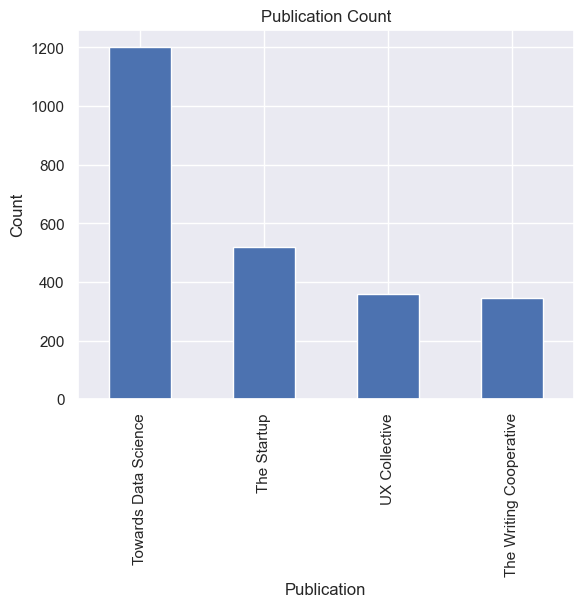

In [133]:
publication_count = df_cleaned['publication'].value_counts()
publication_count.plot(kind='bar')
plt.title('Publication Count')
plt.xlabel('Publication')
plt.ylabel('Count')
plt.show()

In [134]:
publication_count = df_cleaned['publication'].value_counts()
publication_count

publication
Towards Data Science       1201
The Startup                 520
UX Collective               358
The Writing Cooperative     344
Name: count, dtype: int64

In [135]:
1228/2498

0.49159327461969576

In [136]:
df['responses'].min()

0

In [137]:
df['responses'].max()

207

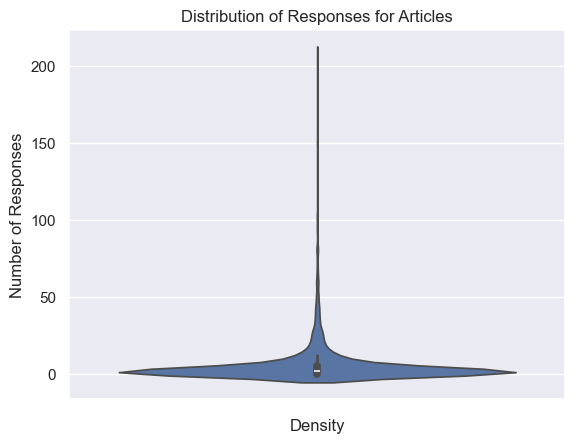

In [138]:
plt.figure()
sns.violinplot(df['responses'])
plt.title('Distribution of Responses for Articles')
plt.xlabel('Density')
plt.ylabel('Number of Responses')
plt.show()

## 3. Understanding Missing Data [1 points]

Let's consider the claps variable in particular.  Filter the data to a smaller copy of the data that only contains those observations that are missing a value for the claps variable.  Be sure to give this subset a name other than the original data frame name. 

*Hint*: the `.isna()` function can be used in the place of a logical statement.

In [139]:
missing_claps_df = df[df['claps'].isna()]
missing_claps_df

,id,url,title,subtitle,claps,responses,reading_time,publication,day,month,year


You can use this space to analyze the dataset that you created at the beginning part of this question.

IndexError: index 0 is out of bounds for axis 0 with size 0

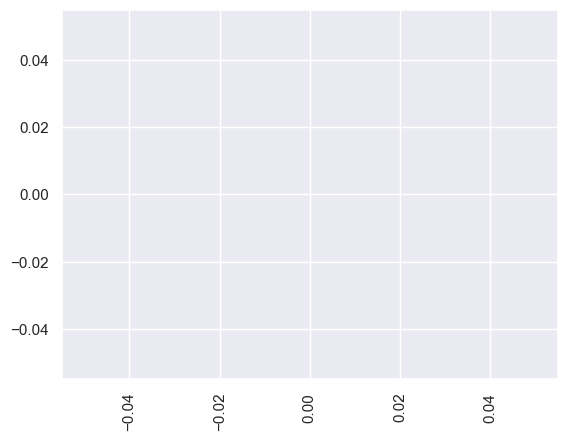

In [140]:
missing_clap_publication_count = missing_claps_df['publication'].value_counts()
missing_clap_publication_count.plot(kind='bar')
plt.title('Publication Count')
plt.xlabel('Publication')
plt.ylabel('Count')
plt.show()

In [ ]:
missing_clap_publication_count = missing_claps_df['publication'].value_counts()
missing_clap_publication_count

publication
The Writing Cooperative    14
Towards Data Science       11
Name: count, dtype: int64

In [ ]:
towards_data_science_count = 11
total_articles_with_missing_claps = 14 + 11  

proportion_towards_data_science = towards_data_science_count / total_articles_with_missing_claps
proportion_towards_data_science

0.44

In [ ]:
missing_claps_df['responses'].min()

0

In [ ]:
missing_claps_df['responses'].max()

0

## 4. Article Responses [3 points]

In this question, we'd like to understand the responses that are earned by each article in the context of its given publication.

**a)** First, generate a data frame that provides the total number of responses recorded for all articles in our data based on the publication.  That is, you should have one number recorded for each publication.

In [ ]:
response_totals = df.groupby('publication')['responses'].sum().reset_index()
response_totals.columns = ['Publication', 'Total_Responses']
response_totals

,Publication,Total_Responses
0,The Startup,7397
1,The Writing Cooperative,2821
2,Towards Data Science,2007
3,UX Collective,1624


**b)** Then, merge the data frame from **part a** into the original data frame for the articles.

In [ ]:
merged_df = pd.merge(df, response_totals, left_on='publication', right_on='Publication', how='left')
merged_df

,id,url,title,subtitle,claps,responses,reading_time,publication,day,month,year,Publication,Total_Responses
0,1,https://towardsdatascience.com/not-all-rainbow...,Not All Rainbows and Sunshine: The Darker Side...,Part 1: The Risks and Ethical Issues…,453,11,9,Towards Data Science,27,1,2023,Towards Data Science,2007
1,2,https://towardsdatascience.com/ethics-in-ai-po...,Ethics in AI: Potential Root Causes for Biased...,An alternative approach to understanding bias ...,311,3,12,Towards Data Science,27,1,2023,Towards Data Science,2007
2,3,https://towardsdatascience.com/python-tuple-th...,"Python Tuple, The Whole Truth and Only the Tru...",NaN,188,0,24,Towards Data Science,27,1,2023,Towards Data Science,2007
3,4,https://towardsdatascience.com/dates-and-subqu...,Dates and Subqueries in SQL,Working with dates in SQL,15,1,4,Towards Data Science,27,1,2023,Towards Data Science,2007
4,5,https://towardsdatascience.com/temporal-differ...,Temporal Differences with Python: First Sample...,NaN,10,0,13,Towards Data Science,27,1,2023,Towards Data Science,2007
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2493,2494,https://medium.com/swlh/brian-chesky-is-an-exa...,Brian Chesky is an Example of What it Means to...,NaN,370,2,7,The Startup,29,1,2023,The Startup,7397
2494,2495,https://medium.com/swlh/5-red-flags-of-online-...,5 Red Flags of Online Business Gurus,How to know which mentors you can’t trust onli...,250,6,8,The Startup,29,1,2023,The Startup,7397
2495,2496,https://writingcooperative.com/recognizing-the...,Recognizing These Three Realities Can Help Set...,NaN,410,10,4,The Writing Cooperative,29,1,2023,The Writing Cooperative,2821
2496,2497,https://writingcooperative.com/i-remember-it-l...,“I Remember It Like It Was Just Yesterday…” Re...,The Role of Emotional Memory in Our Writing,461,7,7,The Writing Cooperative,29,1,2023,The Writing Cooperative,2821


**c)** Now, add a new variable to our articles data that records the proportion of responses in the given publication that are from the article.  That is, you are calculating the share of responses for that publication that are posted to a specific article.  

*Hint:* This can be calculated by dividing two variables that exist in the data from **part b**.

In [ ]:
merged_df['response_proportion'] = merged_df['responses'] / merged_df['Total_Responses']
merged_df

,id,url,title,subtitle,claps,responses,reading_time,publication,day,month,year,Publication,Total_Responses,response_proportion
0,1,https://towardsdatascience.com/not-all-rainbow...,Not All Rainbows and Sunshine: The Darker Side...,Part 1: The Risks and Ethical Issues…,453,11,9,Towards Data Science,27,1,2023,Towards Data Science,2007,0.005481
1,2,https://towardsdatascience.com/ethics-in-ai-po...,Ethics in AI: Potential Root Causes for Biased...,An alternative approach to understanding bias ...,311,3,12,Towards Data Science,27,1,2023,Towards Data Science,2007,0.001495
2,3,https://towardsdatascience.com/python-tuple-th...,"Python Tuple, The Whole Truth and Only the Tru...",NaN,188,0,24,Towards Data Science,27,1,2023,Towards Data Science,2007,0.000000
3,4,https://towardsdatascience.com/dates-and-subqu...,Dates and Subqueries in SQL,Working with dates in SQL,15,1,4,Towards Data Science,27,1,2023,Towards Data Science,2007,0.000498
4,5,https://towardsdatascience.com/temporal-differ...,Temporal Differences with Python: First Sample...,NaN,10,0,13,Towards Data Science,27,1,2023,Towards Data Science,2007,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2493,2494,https://medium.com/swlh/brian-chesky-is-an-exa...,Brian Chesky is an Example of What it Means to...,NaN,370,2,7,The Startup,29,1,2023,The Startup,7397,0.000270
2494,2495,https://medium.com/swlh/5-red-flags-of-online-...,5 Red Flags of Online Business Gurus,How to know which mentors you can’t trust onli...,250,6,8,The Startup,29,1,2023,The Startup,7397,0.000811
2495,2496,https://writingcooperative.com/recognizing-the...,Recognizing These Three Realities Can Help Set...,NaN,410,10,4,The Writing Cooperative,29,1,2023,The Writing Cooperative,2821,0.003545
2496,2497,https://writingcooperative.com/i-remember-it-l...,“I Remember It Like It Was Just Yesterday…” Re...,The Role of Emotional Memory in Our Writing,461,7,7,The Writing Cooperative,29,1,2023,The Writing Cooperative,2821,0.002481


**d)** Finally, which article has the most responses relative to its publication?  What proportion of publication responses are due to that article?

In [ ]:
max_response_proportion = merged_df['response_proportion'].max()
max_response_proportion

0.06477329347284504

In [ ]:
max_response_proportion = merged_df[merged_df['response_proportion'] == 0.06477329347284504]
max_response_proportion

,id,url,title,subtitle,claps,responses,reading_time,publication,day,month,year,Publication,Total_Responses,response_proportion
418,419,https://towardsdatascience.com/how-chatgpt-wor...,How ChatGPT Works: The Model Behind The Bot,A brief introduction to the intuition and meth...,7100,130,8,Towards Data Science,30,1,2023,Towards Data Science,2007,0.064773


The article with the most responses relative to its publication is How ChatGPT Works: The Model Behind The Bot, with 6.48% (0.06477329347284504) of publication responses due to that article.

Remember to keep all your cells and hit the save icon above periodically to checkpoint (save) your results on your local computer. Once you are satisified with your results restart the kernel and run all (Kernel -> Restart & Run All). **Make sure nothing has changed**. Checkpoint and exit (File -> Save and Checkpoint + File -> Close and Halt). Follow the instructions on the Homework 2 Canvas Assignment to submit your notebook to GitHub.  Be sure to also complete the Gradescope component of this assignment.